In [81]:
import torch
import torch.nn.functional as F
import random
import matplotlib.pyplot as plt
%matplotlib inline

In [82]:
# --- MLP ---
# Main differences: more context, word embeddings, hidden layers w. non-linear activations

In [83]:
with open("names.txt", "r") as f:
    words = f.read().splitlines()

chars = sorted(list(set("".join(words))))
stoi = {c:i + 1 for i, c in enumerate(chars)} # {".":0, "a":1, ...}
stoi["."] = 0
itos = {i:c for c, i in stoi.items()} # {0:".", 1:"a", ...}

In [84]:
block_size = 3

def build_dataset(words):
    X, Y = [], []
    for word in words:
        context = [0] * block_size
        for ch in word + ".":
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]
    return torch.tensor(X), torch.tensor(Y)

# Training/dev/test = 0.8/0.1/0.1
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [92]:
C = torch.randn(27, 10) # Embedding matrix (10D)

# Weights and biases (200D hidden layer)
W1 = torch.randn(30, 200) # 30 = 3 (previous context) x 10 (embedding dimension)
b1 = torch.randn(200) # Hidden layer dimensions
W2 = torch.randn(200, 27)
b2 = torch.randn(27)

parameters = [C, W1, b1, W2, b2] # Easy access for parameters

In [93]:
# Track with autograd
for p in parameters:
  p.requires_grad = True
    
sum(p.nelement() for p in parameters) # Total no. of parameters

11897

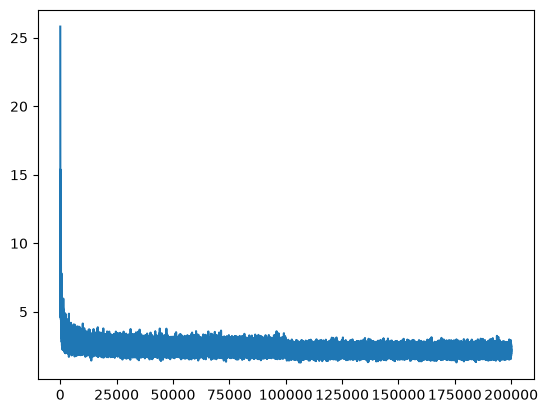

In [89]:
stepi = []
lossi = []

for i in range(200000):
    idx = torch.randint(0, Xtr.shape[0], (32,)) # Mini-batch (32,)
    
    # Forward pass
    embedding = C[Xtr[idx]] # (32, 3, 10)
    h = torch.tanh(embedding.view(-1, 30) @ W1 + b1) # (32, 200) = (32, 30) x (30, 200) + (1, 200)
    logits = h @ W2 + b2 # (32, 27) = (32, 200) x (200, 27) + (1, 27)
    loss = F.cross_entropy(logits, Ytr[idx])

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update weights
    for p in parameters:
        lr = 0.1 if i < 100000 else 0.01
        p.data += -lr * p.grad
        stepi.append(i)
        lossi.append(loss.item())

plt.plot(stepi, lossi)

In [90]:
# Test on dev set
embedding = C[Xdev]
h = torch.tanh(embedding.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1710, grad_fn=<NllLossBackward0>)

In [91]:
# Inference
for _ in range(20):
    out = []
    context = [0] * block_size # Start with "..."
    while True:
        embedding = C[torch.tensor(context)] # (block_size, 10)
        h = torch.tanh(embedding.view(1, -1) @ W1 + b1) # Flatten to (1, block_size * 10) for one context at a time during inference
        logits = h @ W2 + b24
        probs = F.softmax(logits, dim=1)
        idx = torch.multinomial(probs, num_samples=1).item()
        context = context[1:] + [idx]
        out.append(idx)
        if idx == 0:
            break
    
    print("".join(itos[i] for i in out))

fe.
laron.
elhem.
jayden.
kamaeshia.
osmon.
isa.
abdul.
lorerrishalos.
rokiquorayshaylia.
shana.
mackline.
kris.
raiah.
brextin.
atterie.
neeson.
wair.
naeces.
alla.


In [94]:
# --- Learning rate sweep (heuristical) ---
# NOTE: need to reset weights first!

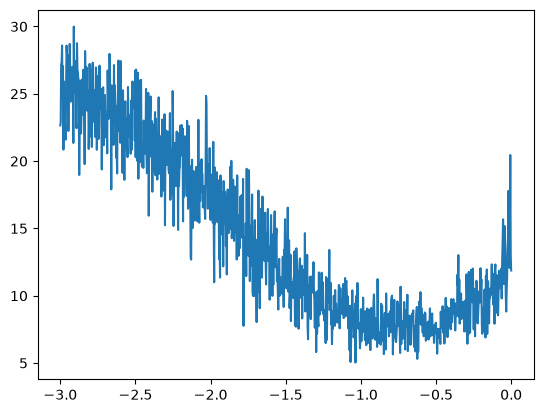

In [95]:
lre = torch.linspace(-3, 0, 1000) # Exponents (1000 evenly-spaced -3 to 0)
lrs = 10**lre

lri = []
lossi = []

for i in range(1000):
    idx = torch.randint(0, X.shape[0], (32,)) # Mini-batch (32,)

    # Forward pass
    embedding = C[X[idx]]
    h = torch.tanh(embedding.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y[idx])

    # Backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # Update
    for p in parameters:
        lr = lrs[i] # Test different lr on each step (technically confounding)
        p.data += -lr * p.grad
        lri.append(lre[i])
        lossi.append(loss.item())

plt.plot(lri, lossi)